# Introduction: Salifort Motors Employee Retention Project

**Business Problem**
Salifort Motors is experiencing a high rate of employee turnover, which incurs significant costs in recruitment, training, and lost productivity. The executive team needs a data-driven approach to understand the primary drivers of this attrition and identify employees who are at high risk of leaving.

**Project Objective**
The goal of this project is to analyze HR data and build a predictive classification model to forecast employee churn. By identifying the key variables that influence an employee's decision to leave—such as workload, performance evaluations, and tenure—we can provide actionable recommendations to leadership to improve retention strategies.

**Data Overview**
The dataset contains 14,999 records of employee metrics, including self-reported satisfaction, project counts, average monthly hours, and compensation tiers. The target variable is `left` (binary: 0 = retained, 1 = left).

# Phase 1: Plan

In this initial phase, we establish the project environment. The objectives are to:
* Import necessary data manipulation and visualization libraries.
* Configure global visualization settings.
* Load the raw dataset and verify its structure.

In [1]:
# Import standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/HR_capstone_dataset.csv')

# Display the first few rows to verify successful load
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Phase 2: Analyze (Data Exploration & Cleaning)

In this phase, we inspect the dataset to understand its dimensions, variable types, and statistical distribution. We will also clean the data by identifying and removing duplicate records, checking for missing values, and examining the class balance of our target variable (`left`).

In [3]:
# Gather basic information about the data
print("Dataframe Information:")
print("-" * 30)
df.info()

print("\nMissing Values:")
print("-" * 30)
print(df.isna().sum())

Dataframe Information:
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB

Missing Values:
------------------------------
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend

In [6]:
# Gather descriptive statistics about the data
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
# Display all column names
print("\nColumn Names:", df.columns.tolist()
      )


Column Names: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [5]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates and reset index
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)

# Verify the new shape
print(f"Shape after removing duplicates: {df_clean.shape}")

Number of duplicate rows: 3008
Shape after removing duplicates: (11991, 10)


### Outlier Detection
We need to identify outliers in continuous variables to determine if they represent data entry errors or legitimate extreme values (like senior employees with long tenure). We will start by examining `time_spend_company`.

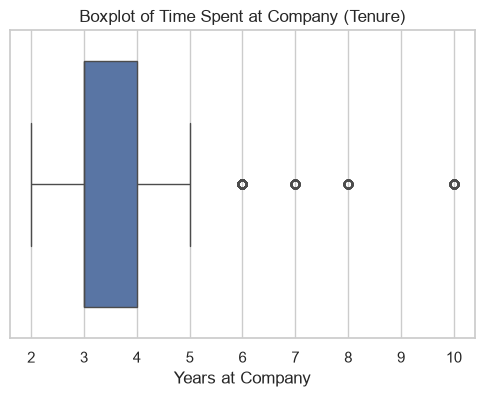

In [10]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean['time_spend_company'])
plt.title('Boxplot of Time Spent at Company (Tenure)')
plt.xlabel('Years at Company')
plt.show()

In [11]:
# Determine the number of rows containing outliers
Q1 = df_clean['time_spend_company'].quantile(0.25)
Q3 = df_clean['time_spend_company'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Filter for rows where time_spend_company exceeds the upper bound
outliers = df_clean[df_clean['time_spend_company'] > upper_bound]

print(f"Number of rows containing outliers in 'time_spend_company': {len(outliers)}")

Number of rows containing outliers in 'time_spend_company': 824


# Phase 3: Construct

# Phase 4: Execute